In [326]:
 # import libraries
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, RandomizedSearchCV
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
import numpy as np
import joblib


In [327]:
# Load and display data
def load_data(url):
  df = pd.read_csv(url)
  return df

In [328]:
def display_categorical(df):
  # display number of unique entries for categorical variables
  display(df['product_category'].value_counts())
  display(df['social_media_platform'].value_counts())
  display(df['review_sentiment'].value_counts())

In [329]:
def data_preprocessing(df, le):
  # create numerical values to represent the date
  df['purchase_date'] = pd.to_datetime(df['purchase_date'])
  df['year'] = df['purchase_date'].dt.year
  df['month']= df['purchase_date'].dt.month
  df['day'] = df['purchase_date'].dt.day
  df['weekday'] = df['purchase_date'].dt.day_of_week
  df['isweekend'] = (df['weekday'] >= 5).astype(int)

  # drop date column
  df.drop(columns='purchase_date', inplace=True)

  # drop id and year columns because they are not relevant to model
  df = df.drop(['customer_id','transaction_id', 'year'], axis=1)

  # get list of numerical columns - return
  numeric_cols = df.select_dtypes(include=[np.number]).columns.drop('isweekend')

  # Label encoding for product category and social media platform columns
  df['social_media_platform'] = le.fit_transform(df['social_media_platform'])
  df['product_category'] = le.fit_transform(df['product_category'])
  # Ordinal encoding for review sentiment column
  sentiment_mapping = {'Negative':0, 'Neutral': 1, 'Positive': 2}
  df['review_sentiment'] = df['review_sentiment']. map(sentiment_mapping)

  # print label mapping
  print("Books = 0\nClothing = 1\nElectronics = 2\nGroceries = 3\nSports = 4")

  return df, numeric_cols

In [330]:
# prep data for machine learning
def prep_data(df):
  X = df.drop('product_category', axis=1)
  y = df['product_category']
  X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
  print(f'X_train shape : {X_train.shape}\nX_test shape : {X_test.shape}\ny_train shape : {y_train.shape}\ny_test shape : {y_test.shape}\n')
  return X,y,X_train,X_test,y_train,y_test



In [331]:
# vanilla random forest model
def normal_rf(X_train,X_test,y_train,y_test):
  rf_1 = RandomForestClassifier(class_weight='balanced')
  rf_1.fit(X_train, y_train)
  y_pred = rf_1.predict(X_test)
  print("Books = 0\nClothing = 1\nElectronics = 2\nGroceries = 3\nSports = 4")
  print(classification_report(y_test, y_pred))

  return rf_1



In [332]:
# random forest with GridSearchCV
def grid_search_rf(X, X_train, X_test, y_train, y_test):
  rf_2 = RandomForestClassifier(random_state=42)

  param_grid = {
      'n_estimators': [50, 100],               # Number of trees
      'max_depth': [None, 4, 10, 20],             # Depth of trees
      'min_samples_split': [2, 5],             # Min samples to split a node
      'min_samples_leaf': [1, 2],              # Min samples at a leaf
      'max_features': ['sqrt', 'log2'],        # Feature selection method
      'bootstrap': [True],
      'class_weight':['balanced']
  }

  rf_grid = GridSearchCV(
    estimator=rf_2,
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=2,
    verbose=2
  )
  rf_grid.fit(X_train, y_train)

  print("Best Parameters:", rf_grid.best_params_)
  best_model = rf_grid.best_estimator_

  importances = best_model.feature_importances_
  features = X.columns

  feat_df = pd.DataFrame({'Feature': features, 'Importance': importances})
  feat_df.sort_values(by='Importance', ascending=False, inplace=True)

  # Plot
  plt.figure(figsize=(10, 6))
  plt.barh(feat_df['Feature'], feat_df['Importance'])
  plt.xlabel("Feature Importance")
  plt.title("Random Forest Feature Importances")
  plt.gca().invert_yaxis()
  plt.show()

  y_pred = best_model.predict(X_test)
  print(classification_report(y_test, y_pred))
  return rf_grid

In [333]:
# random forest with RandomizedSearchCV
def randomized_search(X, X_train, X_test, y_train, y_test):
  rf3 = RandomForestClassifier(class_weight='balanced', random_state=42)

  # Define parameter distribution
  param_dist = {
      'n_estimators': [50, 100, 200, 300],
      'max_depth': [None, 5, 10, 20, 30],
      'min_samples_split': [2, 5, 10],
      'min_samples_leaf': [1, 2, 4],
      'max_features': ['sqrt', 'log2'],
      'bootstrap': [True]
  }

  # Randomized Search
  rf_random = RandomizedSearchCV(
      estimator=rf3,
      param_distributions=param_dist,
      n_iter=50,               # Try 20 random combinations
      cv=3,                    # 3-fold cross-validation
      scoring='accuracy',
      random_state=42,
      n_jobs=-1,
      verbose=2
  )

  # Fit
  rf_random.fit(X_train, y_train)

  # Best model
  best_rf = rf_random.best_estimator_
  print("Best parameters found:", rf_random.best_params_)

  # Evaluate
  y_pred = best_rf.predict(X_test)
  print("=== RandomizedSearch RF Classification")
  print(classification_report(y_test, y_pred))

  return best_rf



In [334]:
# XGBoost Model with GridSearchCV
def xg_boost_model(X, X_train, X_test, y_train, y_test):
  from xgboost import XGBClassifier
  # Define base model
  xgb_base = XGBClassifier(
      objective='multi:softmax',      # For multi-class classification
      num_class=len(set(y)),          # Number of unique classes
      use_label_encoder=False,
      eval_metric='mlogloss',
      random_state=42
  )

  # Define parameter grid
  param_grid = {
      'n_estimators': [50, 100],
      'max_depth': [3, 5, 10],
      'learning_rate': [0.01, 0.1, 0.3],
      'subsample': [0.8, 1.0],
      'colsample_bytree': [0.8, 1.0]
  }

  # GridSearchCV
  xgb_grid = GridSearchCV(
      estimator=xgb_base,
      param_grid=param_grid,
      scoring='accuracy',
      cv=3,
      n_jobs=-1,
      verbose=2
  )

  # Fit to training data
  xgb_grid.fit(X_train, y_train)

  # Best model
  best_xgb = xgb_grid.best_estimator_
  print("Best Parameters:", xgb_grid.best_params_)

  # Evaluate on test data
  y_pred_xgb = best_xgb.predict(X_test)
  print("\n=== Tuned XGBoost Classification Report ===")
  print(classification_report(y_test, y_pred_xgb))

  return best_xgb


In [335]:
# logistic regression model
def logistic_regression_model(X, X_train, X_test, y_train, y_test):
  scaler = StandardScaler()
  X_train_scaled = X_train.copy()
  X_test_scaled = X_test.copy()

  X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
  X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

  logreg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
  logreg.fit(X_train_scaled, y_train)

  # Step 4: Predict and evaluate
  y_pred_logreg = logreg.predict(X_test_scaled)
  print("=== Logistic Regression Classification Report ===")
  print(classification_report(y_test, y_pred_logreg))
  return logreg

In [336]:
# save model
def save_model(model):
  joblib.dump(model, 'product_recommendation_model.pkl')

In [337]:
# load model
def load_model(model):
  loaded_model = joblib.load('random_forest_model.pkl')
  return loaded_model

In [338]:
# make predictions
def predict(model):
  predictions = model.predict(X_test)

In [339]:
# loading data
df = load_data('merged_dataset.csv')
df.head()

,customer_id,social_media_platform,engagement_score,purchase_interest_score,review_sentiment,transaction_id,purchase_amount,purchase_date,product_category,customer_rating
0,190,Twitter,82,4.8,Neutral,1031,333,2024-01-31,Groceries,3.800000
1,190,Twitter,82,4.8,Neutral,1140,401,2024-05-19,Sports,4.900000
2,150,Facebook,96,1.6,Positive,1042,389,2024-02-11,Sports,3.194118
3,150,Facebook,96,1.6,Positive,1046,177,2024-02-15,Books,3.600000
4,162,Twitter,89,2.6,Positive,1079,101,2024-03-19,Books,4.200000


In [340]:
# displaying categorical columns and unique values
display_categorical(df)

,count
product_category,
Sports,59
Electronics,45
Groceries,38
Books,38
Clothing,33


,count
social_media_platform,
Twitter,56
Facebook,47
Instagram,40
LinkedIn,39
TikTok,31


,count
review_sentiment,
Positive,85
Neutral,66
Negative,62


In [341]:
# data preprocessing
le = LabelEncoder()
df, numeric_cols = data_preprocessing(df, le)
df.head()

Books = 0
Clothing = 1
Electronics = 2
Groceries = 3
Sports = 4


,social_media_platform,engagement_score,purchase_interest_score,review_sentiment,purchase_amount,product_category,customer_rating,month,day,weekday,isweekend
0,4,82,4.8,1,333,3,3.800000,1,31,2,0
1,4,82,4.8,1,401,4,4.900000,5,19,6,1
2,0,96,1.6,2,389,4,3.194118,2,11,6,1
3,0,96,1.6,2,177,0,3.600000,2,15,3,0
4,4,89,2.6,2,101,0,4.200000,3,19,1,0


In [342]:
# train-test split data
X,y,X_train,X_test,y_train,y_test = prep_data(df)

X_train shape : (170, 10)
X_test shape : (43, 10)
y_train shape : (170,)
y_test shape : (43,)



In [343]:
# normal random forest model
rf_norm = normal_rf(X_train,X_test,y_train,y_test)

Books = 0
Clothing = 1
Electronics = 2
Groceries = 3
Sports = 4
              precision    recall  f1-score   support

           0       0.86      0.75      0.80         8
           1       1.00      0.67      0.80         6
           2       0.75      0.67      0.71         9
           3       0.89      1.00      0.94         8
           4       0.67      0.83      0.74        12

    accuracy                           0.79        43
   macro avg       0.83      0.78      0.80        43
weighted avg       0.81      0.79      0.79        43



Fitting 3 folds for each of 64 candidates, totalling 192 fits
Best Parameters: {'bootstrap': True, 'class_weight': 'balanced', 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


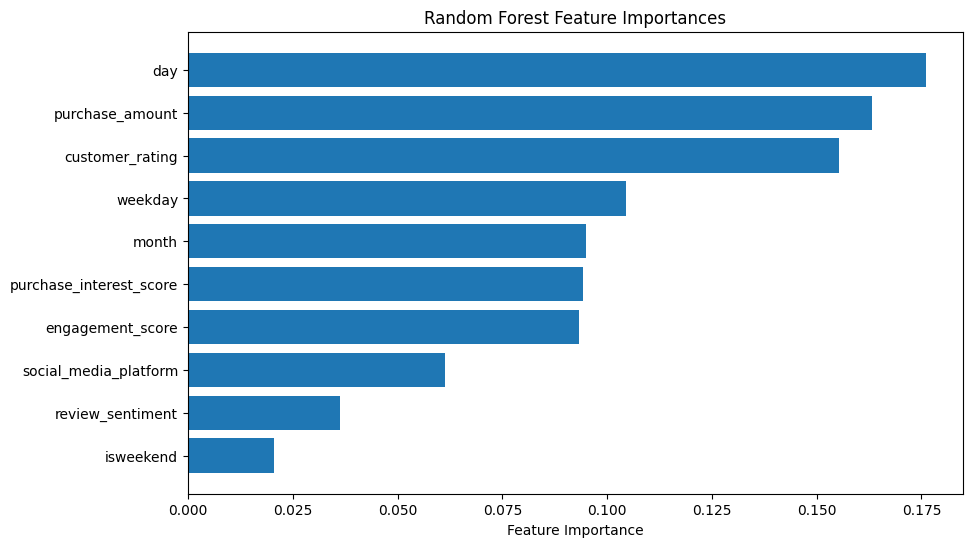

              precision    recall  f1-score   support

           0       1.00      0.50      0.67         8
           1       1.00      0.67      0.80         6
           2       0.55      0.67      0.60         9
           3       0.80      1.00      0.89         8
           4       0.64      0.75      0.69        12

    accuracy                           0.72        43
   macro avg       0.80      0.72      0.73        43
weighted avg       0.77      0.72      0.72        43



In [344]:
# random_forest with GridSearchCV
rf_grid = grid_search_rf(X,X_train,X_test,y_train,y_test)

In [345]:
# random forests with RandomizedSearchCV
rf_random = randomized_search(X,X_train,X_test,y_train,y_test)

Fitting 3 folds for each of 50 candidates, totalling 150 fits
Best parameters found: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None, 'bootstrap': True}
=== RandomizedSearch RF Classification
              precision    recall  f1-score   support

           0       0.83      0.62      0.71         8
           1       1.00      0.67      0.80         6
           2       0.71      0.56      0.62         9
           3       0.80      1.00      0.89         8
           4       0.62      0.83      0.71        12

    accuracy                           0.74        43
   macro avg       0.79      0.74      0.75        43
weighted avg       0.77      0.74      0.74        43



In [346]:
# XGBOOST Model
xgb_model = xg_boost_model(X,X_train,X_test,y_train,y_test)

Fitting 3 folds for each of 72 candidates, totalling 216 fits
Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.3, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}

=== Tuned XGBoost Classification Report ===
              precision    recall  f1-score   support

           0       1.00      0.75      0.86         8
           1       0.67      0.67      0.67         6
           2       0.62      0.56      0.59         9
           3       0.78      0.88      0.82         8
           4       0.64      0.75      0.69        12

    accuracy                           0.72        43
   macro avg       0.74      0.72      0.73        43
weighted avg       0.73      0.72      0.72        43



/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning: [15:26:32] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [347]:
# LogisticRegression model
log_reg_model = logistic_regression_model(X,X_train,X_test,y_train,y_test)

=== Logistic Regression Classification Report ===
              precision    recall  f1-score   support

           0       0.50      0.25      0.33         8
           1       0.43      0.50      0.46         6
           2       0.18      0.22      0.20         9
           3       0.15      0.25      0.19         8
           4       0.25      0.17      0.20        12

    accuracy                           0.26        43
   macro avg       0.30      0.28      0.28        43
weighted avg       0.29      0.26      0.26        43



In [348]:
# save best model
save_model(rf_random)